In [20]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries successfully imported!")

Libraries successfully imported!


In [21]:

df = pd.read_csv(r"D:\ML_PROJECTS\Disease_Prediction_System\heart_disease_uci.csv")

# Create a binary target column from the UCI heart disease 'num' field
df['target'] = (df['num'] > 0).astype(int)
df = df.drop(columns=['num'])

display(df.head())

print(f"Dataset Shape: {df.shape}")

print("\nMissing Values:")
display(df.isnull().sum())

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,target
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,1
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


Dataset Shape: (920, 16)

Missing Values:


id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
target        0
dtype: int64

C:\Users\Mahar Faisal\AppData\Local\Temp\ipykernel_18912\1291432164.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target', data=df, palette='Set2')


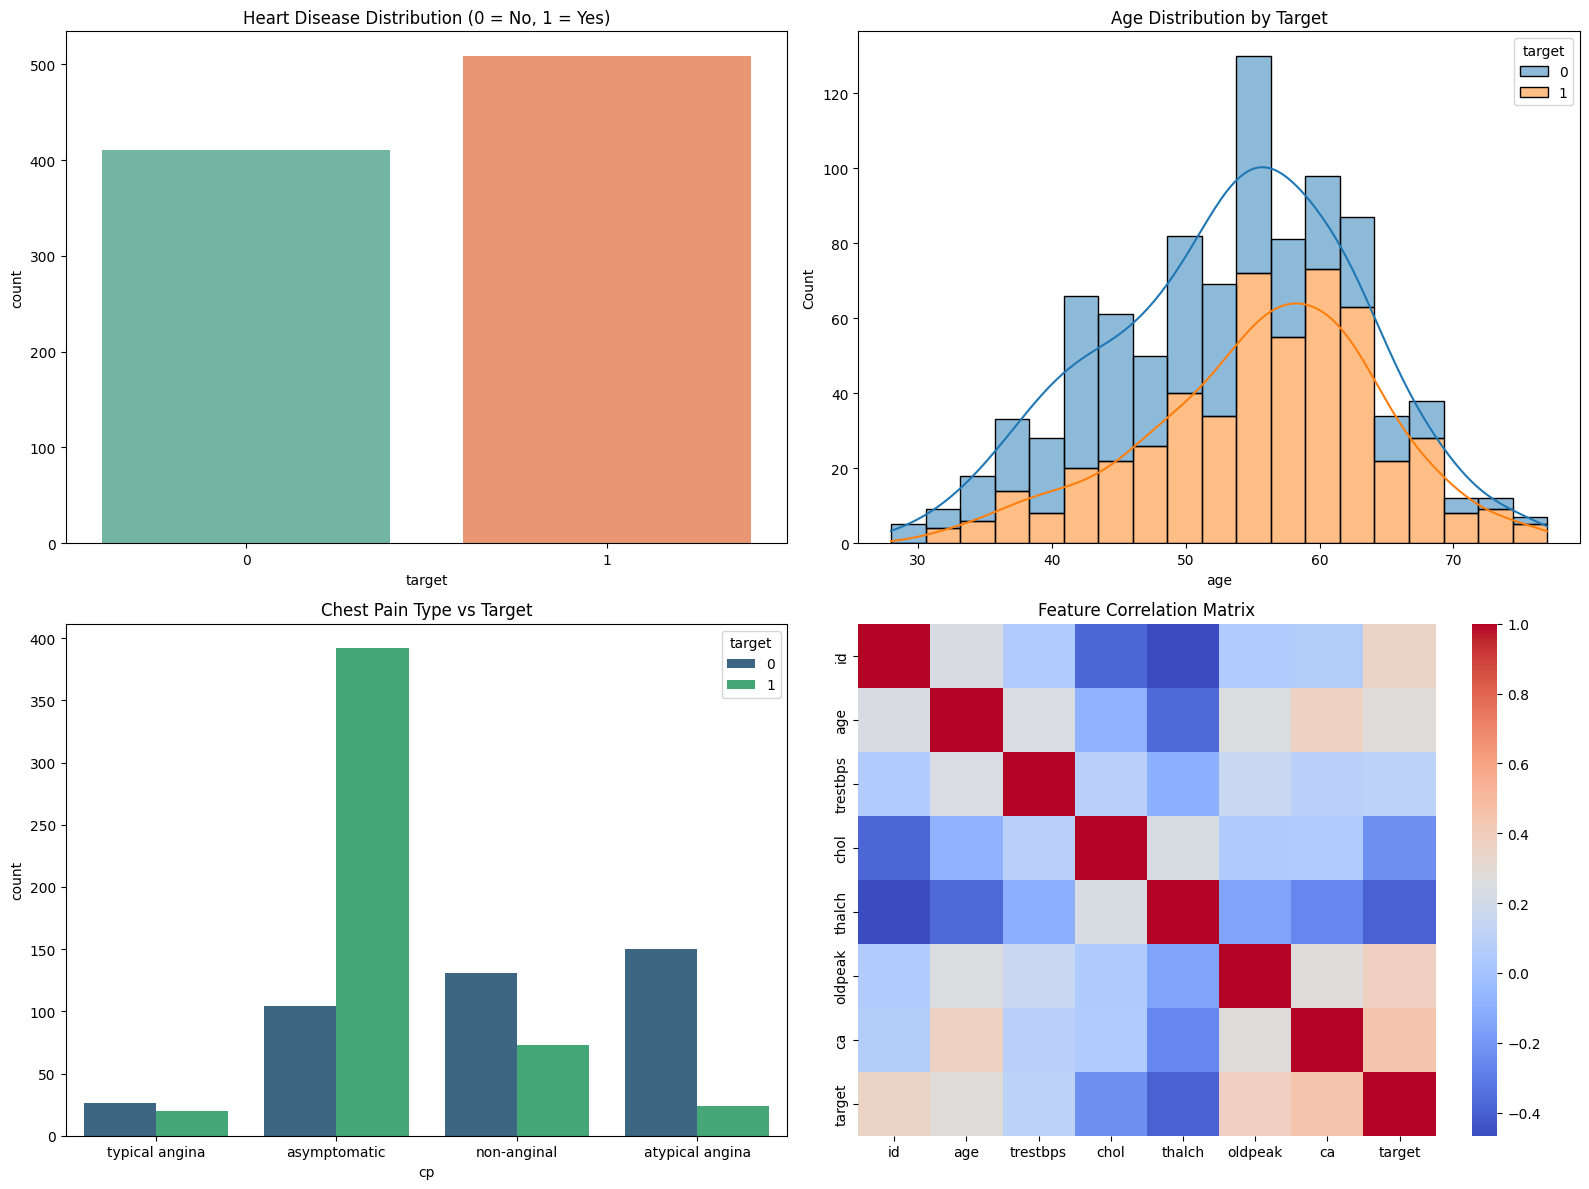

In [22]:

plt.figure(figsize=(16, 12))

# 1. Target Distribution (Imbalanced ya Balanced?)
plt.subplot(2, 2, 1)
sns.countplot(x='target', data=df, palette='Set2')
plt.title('Heart Disease Distribution (0 = No, 1 = Yes)')

# 2. Age vs Target
plt.subplot(2, 2, 2)
sns.histplot(data=df, x='age', hue='target', multiple='stack', kde=True)
plt.title('Age Distribution by Target')

# 3. Chest Pain Type (cp) vs Target
plt.subplot(2, 2, 3)
sns.countplot(x='cp', hue='target', data=df, palette='viridis')
plt.title('Chest Pain Type vs Target')

# 4. Correlation Heatmap (Multicollinearity check)
plt.subplot(2, 2, 4)
corr_matrix = df.select_dtypes(include=np.number).corr()
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm')
plt.title('Feature Correlation Matrix')

plt.tight_layout()
plt.show()

In [23]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
# Replace '?' with NaN and drop those rows to prevent Scaling/Training errors
df = df.replace('?', np.nan).dropna()
df_processed = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# separate Features (X) aur Target (y) 
X = df_processed.drop('target', axis=1)
y = df_processed['target']

# Train-Test Split (80% training, 20% testing)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Feature Scaling: StandardScaler apply 
scaler = StandardScaler()


X_train_scaled = scaler.fit_transform(X_train)


X_test_scaled = scaler.transform(X_test)

print("Data Preprocessing Successful!")
print(f"Training features shape: {X_train_scaled.shape}")
print(f"Testing features shape: {X_test_scaled.shape}")

Data Preprocessing Successful!
Training features shape: (239, 21)
Testing features shape: (60, 21)


In [24]:

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


models = {
    "Logistic Regression": LogisticRegression(),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "SVM": SVC(kernel='rbf'),
    "Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

results = []
print("Training Models and Calculating Metrics...\n")


for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred)
    })


results_df = pd.DataFrame(results).sort_values(by="Accuracy", ascending=False)
display(results_df)

Training Models and Calculating Metrics...



,Model,Accuracy,Precision,Recall,F1 Score
1,KNN,0.833333,0.909091,0.714286,0.800000
0,Logistic Regression,0.816667,0.840000,0.750000,0.792453
2,SVM,0.800000,0.833333,0.714286,0.769231
5,Random Forest,0.783333,0.857143,0.642857,0.734694
4,Decision Tree,0.733333,0.750000,0.642857,0.692308
3,Naive Bayes,0.633333,1.000000,0.214286,0.352941


C:\Users\Mahar Faisal\AppData\Local\Temp\ipykernel_18912\1370170549.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Accuracy', y='Model', data=results_df, palette='Blues_r')


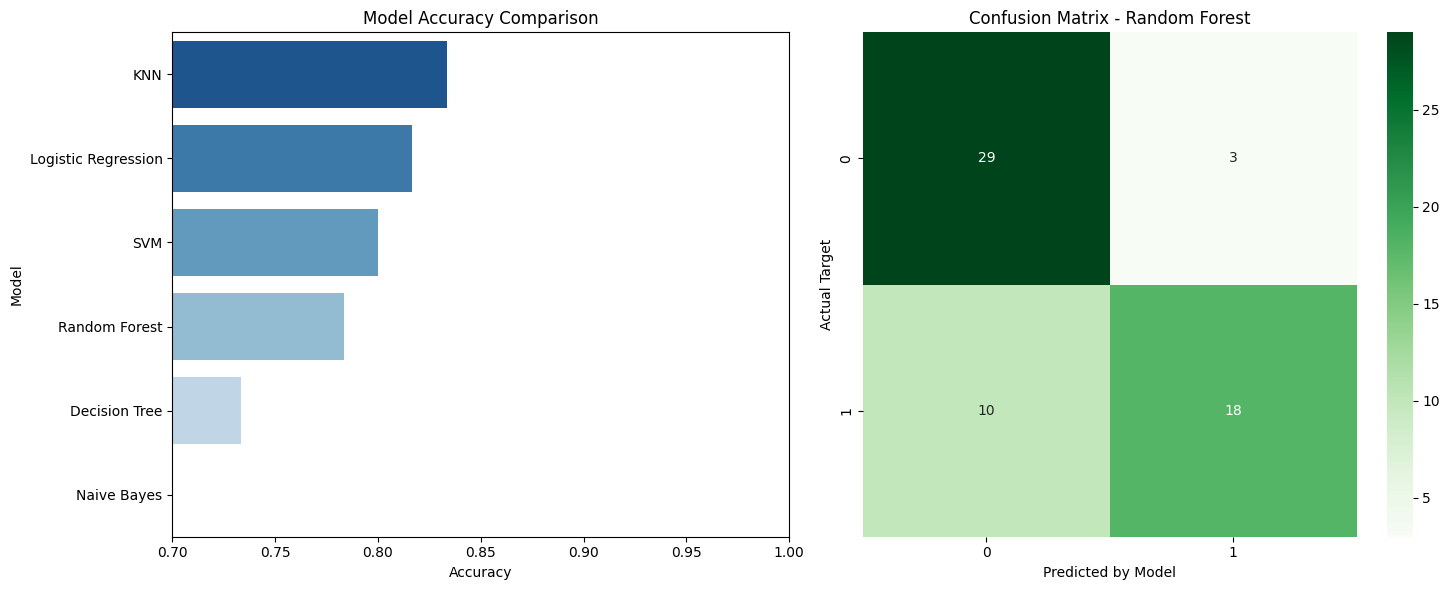

C:\Users\Mahar Faisal\AppData\Local\Temp\ipykernel_18912\1370170549.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feat_imp_df, palette='magma')


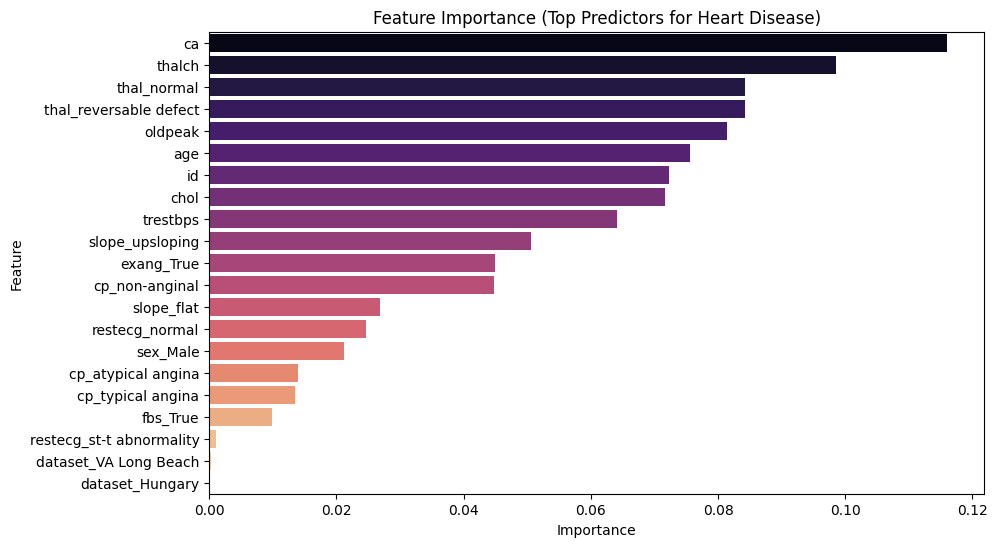

In [25]:

from sklearn.metrics import confusion_matrix

plt.figure(figsize=(15, 6))


plt.subplot(1, 2, 1)
sns.barplot(x='Accuracy', y='Model', data=results_df, palette='Blues_r')
plt.title('Model Accuracy Comparison')
plt.xlim(0.7, 1.0)


best_model = RandomForestClassifier(n_estimators=100, random_state=42)
best_model.fit(X_train_scaled, y_train)
y_pred_best = best_model.predict(X_test_scaled)

cm = confusion_matrix(y_test, y_pred_best)

plt.subplot(1, 2, 2)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted by Model')
plt.ylabel('Actual Target')

plt.tight_layout()
plt.show()


importances = best_model.feature_importances_
feature_names = X.columns
feat_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feat_imp_df, palette='magma')
plt.title('Feature Importance (Top Predictors for Heart Disease)')
plt.show()